# ELI Index Diagnostics — E3SM Hindcast (ne30pg2)

This notebook starts from the monthly ELI index files produced by
`0_run_eli_index_e3sm.ipynb`.

It computes drift-corrected ELI anomalies, evaluates ACC and RMSE skill
against the observed ERSSTv5-based ELI, and produces lead-time diagnostic
plots.

**Prerequisites:** run `0_run_eli_index_e3sm.ipynb` first to generate  
`OUTDIR/E3SMLE{mm}_ELI_N{nens}_M{nlead}.nc`.

In [15]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import re
from pathlib import Path

# Resolve native-library paths from the active kernel.
_env_prefix = sys.prefix
_proj_path  = os.path.join(_env_prefix, "share", "proj")
if os.path.isfile(os.path.join(_proj_path, "proj.db")):
    os.environ["CONDA_PREFIX"] = _env_prefix
    os.environ["PROJ_LIB"]    = _proj_path
    os.environ["PROJ_DATA"]   = _proj_path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import pearsonr

from esp_lab import stats
from esp_lab.utils import mov_utils as mov
from esp_lab.paths import (
    S2D_DIAG_ROOT,
    E3SMLE_DIAG_DIR,
    CESM_SMYLE_DIAG_DIR,
    NMME_DIAG_DIR,
    MODES_VARIABILITY_DIAG_DIR,
)

print(f"Python      : {sys.executable}")
print(f"CONDA_PREFIX: {os.environ.get('CONDA_PREFIX', '(not set)')}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python      : /global/homes/z/zhan391/.conda/envs/e3sm_analysis/bin/python
CONDA_PREFIX: /global/homes/z/zhan391/.conda/envs/e3sm_analysis


## Configuration — fill in ALL fields before running

Fields left as `None` will cause the **Validate** cell to raise an error.

In [16]:
from pathlib import Path
import numpy as np

# ------------------------------------------------------------------ #
#  PATHS
# ------------------------------------------------------------------ #

# -----------------------------------------------------------------------------
# Directory setup
# -----------------------------------------------------------------------------
# Override the root for a different workspace with ESP_LAB_S2D_DIAG_ROOT.
DIAG_ROOT = S2D_DIAG_ROOT
E3SMLE_OUTDIR = E3SMLE_DIAG_DIR
CESM_SMYLE_OUTDIR = CESM_SMYLE_DIAG_DIR
SMYLE_BENCHMARK_DIR = str(CESM_SMYLE_OUTDIR)
NMME_OUTDIR = NMME_DIAG_DIR
MODES_OUTDIR = MODES_VARIABILITY_DIAG_DIR


# Directory where 0_run_eli_index_e3sm.ipynb wrote its output.
ELI_DATA_DIR  = E3SMLE_OUTDIR

# Observational ELI (ERSSTv5), provided by L. Vroekel.
OBS_ELI_FILE  = Path(
    "/global/cfs/cdirs/e3sm/lvroekel/ELI_ERSSTv5_1854.01-2020.05.xlsx"
)

# Diagnostics output directory.
OUTDIR        = E3SMLE_OUTDIR

# Figure output directory.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", str(part).strip()).strip("_").lower()
        if text:
            clean_parts.append(text)
    return "_".join(clean_parts) + f".{ext.lstrip('.')}"


# ------------------------------------------------------------------ #
#  HINDCAST EXPERIMENT
# ------------------------------------------------------------------ #

CASE_PREFIX = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"

START_YEAR  = 1980
END_YEAR    = 2018
EXCL_YEAR   = None

INIT_MONTHS = [5, 11]     # May and November starts

lead_years = [y for y in np.arange(START_YEAR, END_YEAR + 1) if y != EXCL_YEAR]

# ------------------------------------------------------------------ #
#  ENSEMBLE
# ------------------------------------------------------------------ #

CASE_NENS = 10
MEMBERS   = [f"EN{i:02d}" for i in range(CASE_NENS)]
NLEAD     = 24

# ------------------------------------------------------------------ #
#  CLIMATOLOGY WINDOW (for drift removal)
# ------------------------------------------------------------------ #

CLIM_Y0 = 1980
CLIM_Y1 = 2010

# ------------------------------------------------------------------ #
#  RUN CONTROL
# ------------------------------------------------------------------ #

OVERWRITE_OUTPUT = True

print(f"START_YEAR  : {START_YEAR}")
print(f"END_YEAR    : {END_YEAR}")
print(f"INIT_MONTHS : {INIT_MONTHS}")
print(f"CASE_NENS   : {CASE_NENS}")
print(f"NLEAD       : {NLEAD}")
print(f"CLIM window : {CLIM_Y0}–{CLIM_Y1}")

START_YEAR  : 1980
END_YEAR    : 2018
INIT_MONTHS : [5, 11]
CASE_NENS   : 10
NLEAD       : 24
CLIM window : 1980–2010


## Validate — run this before anything else

In [17]:
_required = {
    "ELI_DATA_DIR":  ELI_DATA_DIR,
    "OBS_ELI_FILE":  OBS_ELI_FILE,
    "OUTDIR":        OUTDIR,
    "INIT_MONTHS":   INIT_MONTHS,
}
_missing = [k for k, v in _required.items() if v is None]
if _missing:
    raise ValueError(
        "Required fields are still None:\n" + "\n".join(f"  {k}" for k in _missing)
    )

_errors = []
if not ELI_DATA_DIR.is_dir():
    _errors.append(f"ELI_DATA_DIR not found: {ELI_DATA_DIR}")
if not OBS_ELI_FILE.is_file():
    _errors.append(f"OBS_ELI_FILE not found: {OBS_ELI_FILE}")

for m in INIT_MONTHS:
    _f = ELI_DATA_DIR / f"E3SMLE{m:02d}_ELI_N{CASE_NENS:02d}_M{NLEAD:02d}.nc"
    if not _f.is_file():
        _errors.append(f"ELI index file not found: {_f}")
if _errors:
    raise FileNotFoundError(
        "Path validation failed (run 0_run_eli_index_e3sm.ipynb first):\n"
        + "\n".join(_errors)
    )

OUTDIR.mkdir(parents=True, exist_ok=True)

print("Configuration valid ✓")
print(f"  ELI_DATA_DIR : {ELI_DATA_DIR}")
print(f"  OBS_ELI_FILE : {OBS_ELI_FILE}")
print(f"  OUTDIR       : {OUTDIR}")
for m in INIT_MONTHS:
    _f = ELI_DATA_DIR / f"E3SMLE{m:02d}_ELI_N{CASE_NENS:02d}_M{NLEAD:02d}.nc"
    print(f"  ELI file ({m:02d}) : {_f.name}  ✓")

Configuration valid ✓
  ELI_DATA_DIR : /global/cfs/cdirs/e3sm/zhan391/s2d_diag/E3SMLE
  OBS_ELI_FILE : /global/cfs/cdirs/e3sm/lvroekel/ELI_ERSSTv5_1854.01-2020.05.xlsx
  OUTDIR       : /global/cfs/cdirs/e3sm/zhan391/s2d_diag/E3SMLE
  ELI file (05) : E3SMLE05_ELI_N10_M24.nc  ✓
  ELI file (11) : E3SMLE11_ELI_N10_M24.nc  ✓


## 1.  Load observational ELI

The Excel file contains a monthly ELI time series derived from ERSSTv5.
Each column header is a year; each row is a calendar month (0-indexed).
Values are converted to an `xarray.DataArray` with a monthly time axis.

In [18]:
df_obs = pd.read_excel(OBS_ELI_FILE)

# Collect all available years in column order.
obs_years = [c for c in df_obs.columns if isinstance(c, (int, np.integer))]

times_obs    = []
eli_obs_vals = []
for yr in obs_years:
    for mo in range(12):
        val = df_obs[yr].iloc[mo]
        times_obs.append(pd.Timestamp(year=int(yr), month=mo + 1, day=1))
        eli_obs_vals.append(float(val) if pd.notna(val) else np.nan)

obs_time = pd.DatetimeIndex(times_obs)
eli_obs = xr.DataArray(
    np.array(eli_obs_vals, dtype=np.float32),
    dims="time",
    coords={"time": obs_time},
    name="eli_obs",
    attrs={
        "long_name": "Observed Equatorial Longitude Index (ERSSTv5)",
        "units": "degrees_east",
        "source": str(OBS_ELI_FILE),
    },
)

# Clip to model verification period (with buffer for drift removal).
eli_obs = eli_obs.sel(time=slice(str(START_YEAR - 2), str(END_YEAR + 2)))

# Monthly climatology over the base period for anomaly computation.
obs_clim_mask = (
    (eli_obs.time.dt.year >= CLIM_Y0) &
    (eli_obs.time.dt.year <= CLIM_Y1)
)
obs_clim = eli_obs.isel(time=obs_clim_mask).groupby("time.month").mean()

eli_obs_anom = eli_obs.groupby("time.month") - obs_clim
eli_obs_anom.name = "eli_obs_anom"
eli_obs_anom.attrs = {
    "long_name": "Observed ELI anomaly (ERSSTv5)",
    "units": "degrees_east",
}

print(f"Observational ELI: {len(eli_obs)} months")
print(f"  period : {str(eli_obs.time.values[0])[:10]} — {str(eli_obs.time.values[-1])[:10]}")
print(f"  min/max: {float(eli_obs.min()):.2f} / {float(eli_obs.max()):.2f}°E")
print(f"  mean   : {float(eli_obs.mean()):.2f}°E")
print(f"\nObs anomaly std : {float(eli_obs_anom.std()):.2f}°E")

Observational ELI: 516 months
  period : 1978-01-01 — 2020-12-01
  min/max: 143.92 / 222.66°E
  mean   : 162.60°E

Obs anomaly std : 9.03°E


## 2.  Load model ELI

In [19]:
# Load one NetCDF per init month produced by 0_run_eli_index_e3sm.ipynb.
# Shape: (Y=init_year, L=lead_month, M=member).

eli_model = {}  # keyed by init_month
eli_time  = {}  # absolute calendar time for (Y, L) grid

for m in INIT_MONTHS:
    ncfile = ELI_DATA_DIR / f"E3SMLE{m:02d}_ELI_N{CASE_NENS:02d}_M{NLEAD:02d}.nc"
    ds = xr.open_dataset(ncfile).load()
    eli_model[m] = ds["eli"]

    # Build absolute target calendar: init year + lead offset (months).
    # Lead 1 = month after init; e.g. init Nov 1980 + lead 1 = Dec 1980.
    years_da = ds["Y"].values
    leads_da = ds["L"].values
    t_grid = np.array(
        [
            [
                pd.Timestamp(year=int(yr), month=m, day=1)
                + pd.DateOffset(months=int(lead))
                for lead in leads_da
            ]
            for yr in years_da
        ],
        dtype="datetime64[ns]",
    )
    eli_time[m] = xr.DataArray(
        t_grid,
        dims=("Y", "L"),
        coords={"Y": years_da, "L": leads_da},
        name="time",
    )

    ds.close()

    n_valid = int(np.isfinite(eli_model[m]).sum())
    n_total = int(eli_model[m].size)
    print(f"Init month {m:02d}: {eli_model[m].dims}  {eli_model[m].shape}  "
          f"({n_valid}/{n_total} valid values)")
    print(f"  range: {float(eli_model[m].min()):.2f} – {float(eli_model[m].max()):.2f}°E")

Init month 05: ('Y', 'L', 'M')  (39, 24, 10)  (9360/9360 valid values)
  range: 137.23 – 196.19°E
Init month 11: ('Y', 'L', 'M')  (39, 24, 10)  (9360/9360 valid values)
  range: 136.04 – 200.44°E


## 3.  Drift removal

For each init month, subtract the lead-dependent ELI climatology computed
over the `CLIM_Y0`–`CLIM_Y1` base period.  The result is an ELI *anomaly*
relative to the model's own drift, aligned with the observed anomaly for
skill comparisons.

In [20]:
eli_dd    = {}   # drift-corrected model ELI anomaly  (Y, L, M)
eli_drift = {}   # lead-dependent model ELI climatology (L,)

for m in INIT_MONTHS:
    da = eli_model[m]               # (Y, L, M)
    years = da["Y"].values

    # Select climatology years.
    clim_mask = (years >= CLIM_Y0) & (years <= CLIM_Y1)
    da_clim = da.isel(Y=clim_mask)

    # Lead-dependent mean over ensemble members and clim years.
    drift = da_clim.mean(dim=("Y", "M"))   # (L,)
    anom  = da - drift                      # (Y, L, M)  — broadcast over Y and M

    eli_dd[m]    = anom
    eli_drift[m] = drift

    print(f"Init month {m:02d}:  drift range = "
          f"{float(drift.min()):.2f} – {float(drift.max()):.2f}°E  "
          f"| anom mean = {float(anom.mean()):.3f}°E")

Init month 05:  drift range = 144.92 – 169.45°E  | anom mean = 0.487°E
Init month 11:  drift range = 146.35 – 170.30°E  | anom mean = 0.292°E


## 4.  Skill computation

For each init month and each lead, compute ACC (anomaly correlation) and
normalised RMSE between the ensemble-mean ELI anomaly and the observed ELI
anomaly, verifying only over the years in `lead_years`.

In [21]:
skill = {}   # keyed by init_month

for m in INIT_MONTHS:
    da_anom = eli_dd[m]              # (Y, L, M)
    t_grid  = eli_time[m]            # (Y, L) datetime64
    leads   = da_anom["L"].values

    acc   = np.full(len(leads), np.nan)
    pval  = np.full(len(leads), np.nan)
    rmse  = np.full(len(leads), np.nan)
    nrmse = np.full(len(leads), np.nan)

    for li, lead in enumerate(leads):
        ens_mean = da_anom.isel(L=li).mean(dim="M").values   # (Y,)
        t_lead   = pd.DatetimeIndex(t_grid.isel(L=li).values)

        # Align model ensemble mean with observed anomaly at each target month.
        obs_vals = np.array(
            [
                float(
                    eli_obs_anom.sel(time=t, method="nearest",
                                     tolerance=pd.Timedelta("31D"))
                ) if (eli_obs_anom.time.values[0] <= t.to_datetime64()
                      <= eli_obs_anom.time.values[-1])
                else np.nan
                for t in t_lead
            ],
            dtype=np.float32,
        )

        valid = np.isfinite(ens_mean) & np.isfinite(obs_vals)
        if valid.sum() < 5:
            continue

        r, p  = pearsonr(ens_mean[valid], obs_vals[valid])
        acc[li]   = r
        pval[li]  = p
        e         = ens_mean[valid] - obs_vals[valid]
        rmse[li]  = np.sqrt(np.mean(e ** 2))
        nrmse[li] = rmse[li] / (np.std(obs_vals[valid]) + 1e-12)

    skill[m] = xr.Dataset(
        {
            "acc":   xr.DataArray(acc,   dims="lead", coords={"lead": leads}),
            "pval":  xr.DataArray(pval,  dims="lead", coords={"lead": leads}),
            "rmse":  xr.DataArray(rmse,  dims="lead", coords={"lead": leads},
                                  attrs={"units": "degrees_east"}),
            "nrmse": xr.DataArray(nrmse, dims="lead", coords={"lead": leads}),
        }
    )

    print(f"Init month {m:02d}:")
    print(f"  ACC  lead 1 = {acc[0]:.3f},  lead 12 = {acc[11]:.3f},  lead 24 = {acc[-1]:.3f}")
    print(f"  RMSE lead 1 = {rmse[0]:.2f}°E, lead 12 = {rmse[11]:.2f}°E, lead 24 = {rmse[-1]:.2f}°E")

Init month 05:
  ACC  lead 1 = 0.726,  lead 12 = 0.062,  lead 24 = -0.054
  RMSE lead 1 = 5.10°E, lead 12 = 8.43°E, lead 24 = 8.76°E
Init month 11:
  ACC  lead 1 = 0.952,  lead 12 = 0.404,  lead 24 = 0.135
  RMSE lead 1 = 2.81°E, lead 12 = 5.64°E, lead 24 = 6.48°E


## 5.  ELI target-month time series vs observations

Plot January-target ELI anomalies in the same multi-panel system used by
`4_refactor_sst_skill_ts.ipynb`: rows are initialization months, columns are
the first- and second-winter target leads, with ACC and nRMSE annotations.


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_eli_time_series.png


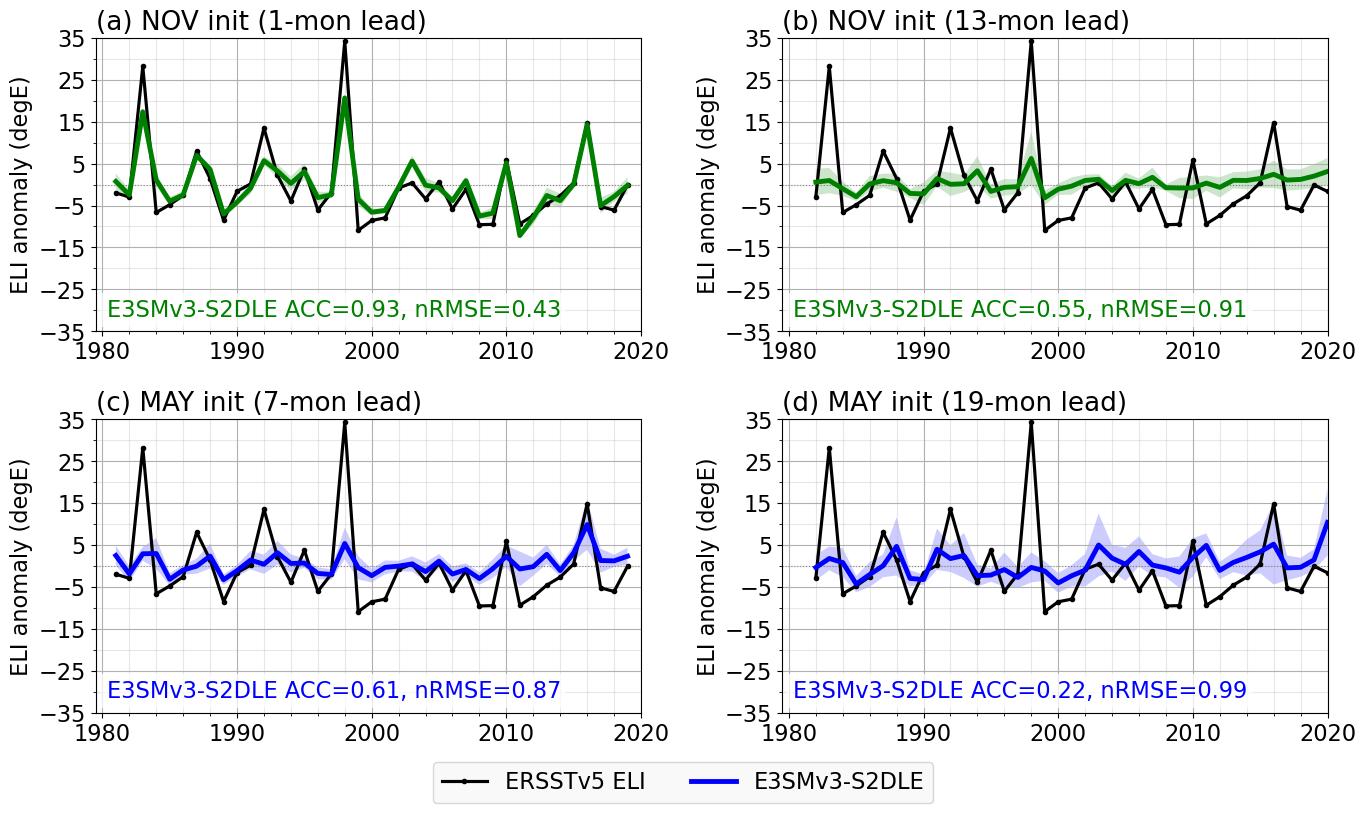

In [22]:

# -----------------------------
# Plot January-target ELI time series
# -----------------------------
# This follows the figure system in 4_refactor_sst_skill_ts.ipynb, adapted to the
# monthly ELI index.  Lead choices target January for first and second winters.
startmonths_requested = [11, 5]
target_leads = {
    11: [2, 14],   # NOV init -> Jan target, first and second winter
    5:  [8, 20],   # MAY init -> Jan target, first and second winter
}
startmonths_plot = [m for m in startmonths_requested if m in INIT_MONTHS]
nrow = len(startmonths_plot)
ncol = 2

fontz = 18
title_fontz = fontz * 1.05
tick_fontz = fontz * 0.9
legend_fontz = fontz * 0.9
annotation_fontz = fontz * 0.9

fig_width = 14
row_height = fig_width * 0.6 / ncol
line_width = 3.5
obs_marker_size = 6
e3sm_spread_alpha = 0.2
grid_minor_alpha = 0.3
annotation_box = dict(facecolor="white", alpha=0.75, edgecolor="none")
e3sm_annotation_xy = (0.02, 0.05)

plot_ylim = (-35, 35)
major_yticks = np.arange(plot_ylim[0], plot_ylim[1] + 1, 10)
minor_yticks = np.arange(plot_ylim[0] + 5, plot_ylim[1], 5)
plot_xmin = START_YEAR - 0.5
plot_xmax = END_YEAR + 1.5
major_years = np.arange(1980, 2021, 10)
minor_years = np.arange(1980, 2021, 2)

hindcast_label = {11: "NOV", 5: "MAY"}
hindcast_color = {11: "g", 5: "b"}
e3sm_label = "E3SMv3-S2DLE"
obs_color = "k"
figlabs = [["(a)", "(c)"], ["(b)", "(d)"]]
field = "ELI"
figfmt = "png"
period = f"{START_YEAR}-{END_YEAR}"
figname = figure_filename("eli", "time_series", ext=figfmt)
dpi = 300

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": title_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
    "legend.fontsize": legend_fontz,
})
fig = plt.figure(figsize=(fig_width, row_height * nrow))


def _obs_values_at_times(times):
    return np.array(
        [
            float(
                eli_obs_anom.sel(
                    time=pd.Timestamp(t),
                    method="nearest",
                    tolerance=pd.Timedelta("31D"),
                )
            )
            if (eli_obs_anom.time.values[0] <= pd.Timestamp(t).to_datetime64()
                <= eli_obs_anom.time.values[-1])
            else np.nan
            for t in times
        ],
        dtype=float,
    )


for i, sm in enumerate(startmonths_plot):
    ax = fig.add_subplot(nrow, ncol, i * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, i * 2 + 2)

    for a in [ax, ax2]:
        a.set_ylim(plot_ylim)
        a.set_yticks(major_yticks)
        a.set_yticks(minor_yticks, minor=True)
        a.set_xlim([plot_xmin, plot_xmax])
        a.set_xticks(major_years)
        a.set_xticks(minor_years, minor=True)
        a.tick_params(axis="both", labelsize=tick_fontz)
        a.grid(True, which="major")
        a.grid(True, which="minor", alpha=grid_minor_alpha)
        a.axhline(0, color="0.5", linewidth=0.8, linestyle=":")
        a.set_ylabel("ELI anomaly (degE)", fontsize=tick_fontz)

    for col_idx, (ax_panel, target_L) in enumerate(zip([ax, ax2], target_leads[sm])):
        available_L = eli_dd[sm].L.values
        if target_L not in available_L:
            ax_panel.set_title(f"L={target_L} not available", loc="left", fontsize=title_fontz)
            continue

        data = eli_dd[sm].sel(L=target_L)
        tmp_time = eli_time[sm].sel(L=target_L)
        years_plot = pd.DatetimeIndex(tmp_time.values).year
        obs_vals = _obs_values_at_times(tmp_time.values)

        valid = np.isfinite(years_plot) & np.isfinite(obs_vals)
        data_plot = data.isel(Y=valid)
        years_valid = years_plot[valid]
        obs_valid = obs_vals[valid]

        skill_row = skill[sm].sel(lead=target_L)
        acc = float(skill_row.acc.values)
        nrmse = float(skill_row.nrmse.values)

        lead = int(target_L) - 1
        titl = f"{hindcast_label[sm]} init ({lead}-mon lead)"
        figlabel = figlabs[col_idx][i]
        ax_panel.set_title(figlabel + " " + titl, loc="left", fontsize=title_fontz)

        datamean = data_plot.mean("M")
        datastd = data_plot.std("M")

        ax_panel.plot(
            years_valid,
            obs_valid,
            color=obs_color,
            marker=".",
            markersize=obs_marker_size,
            linewidth=line_width * 0.65,
            label="ERSSTv5 ELI",
        )
        ax_panel.plot(
            years_valid,
            datamean,
            color=hindcast_color[sm],
            linewidth=line_width,
            label=e3sm_label,
        )
        ax_panel.fill_between(
            years_valid,
            (datamean - datastd).values,
            (datamean + datastd).values,
            fc=hindcast_color[sm],
            alpha=e3sm_spread_alpha,
        )
        ax_panel.text(
            *e3sm_annotation_xy,
            f"{e3sm_label} ACC={acc:3.2f}, nRMSE={nrmse:3.2f}",
            transform=ax_panel.transAxes,
            fontsize=annotation_fontz,
            color=hindcast_color[sm],
            bbox=annotation_box,
        )

handles, labels = ax_panel.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.01),
    frameon=True,
    facecolor="#f9f9f9",
    edgecolor="lightgray",
    framealpha=0.9,
)

fig.tight_layout(rect=[0, 0.06, 1, 1])
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="eli_time_series",
    title=f"{field} Time Series",
    caption=f"Verification period: {period}",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()


## 6.  ACC and nRMSE skill vs lead time

Use the same two-column ACC/nRMSE figure system as
`4_refactor_sst_skill_ts.ipynb`: one row per initialization month plus an
ALL-init mean row. Open ACC markers show all leads; filled markers indicate
correlations with `p < 0.1`.


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_eli_acc_skill.png


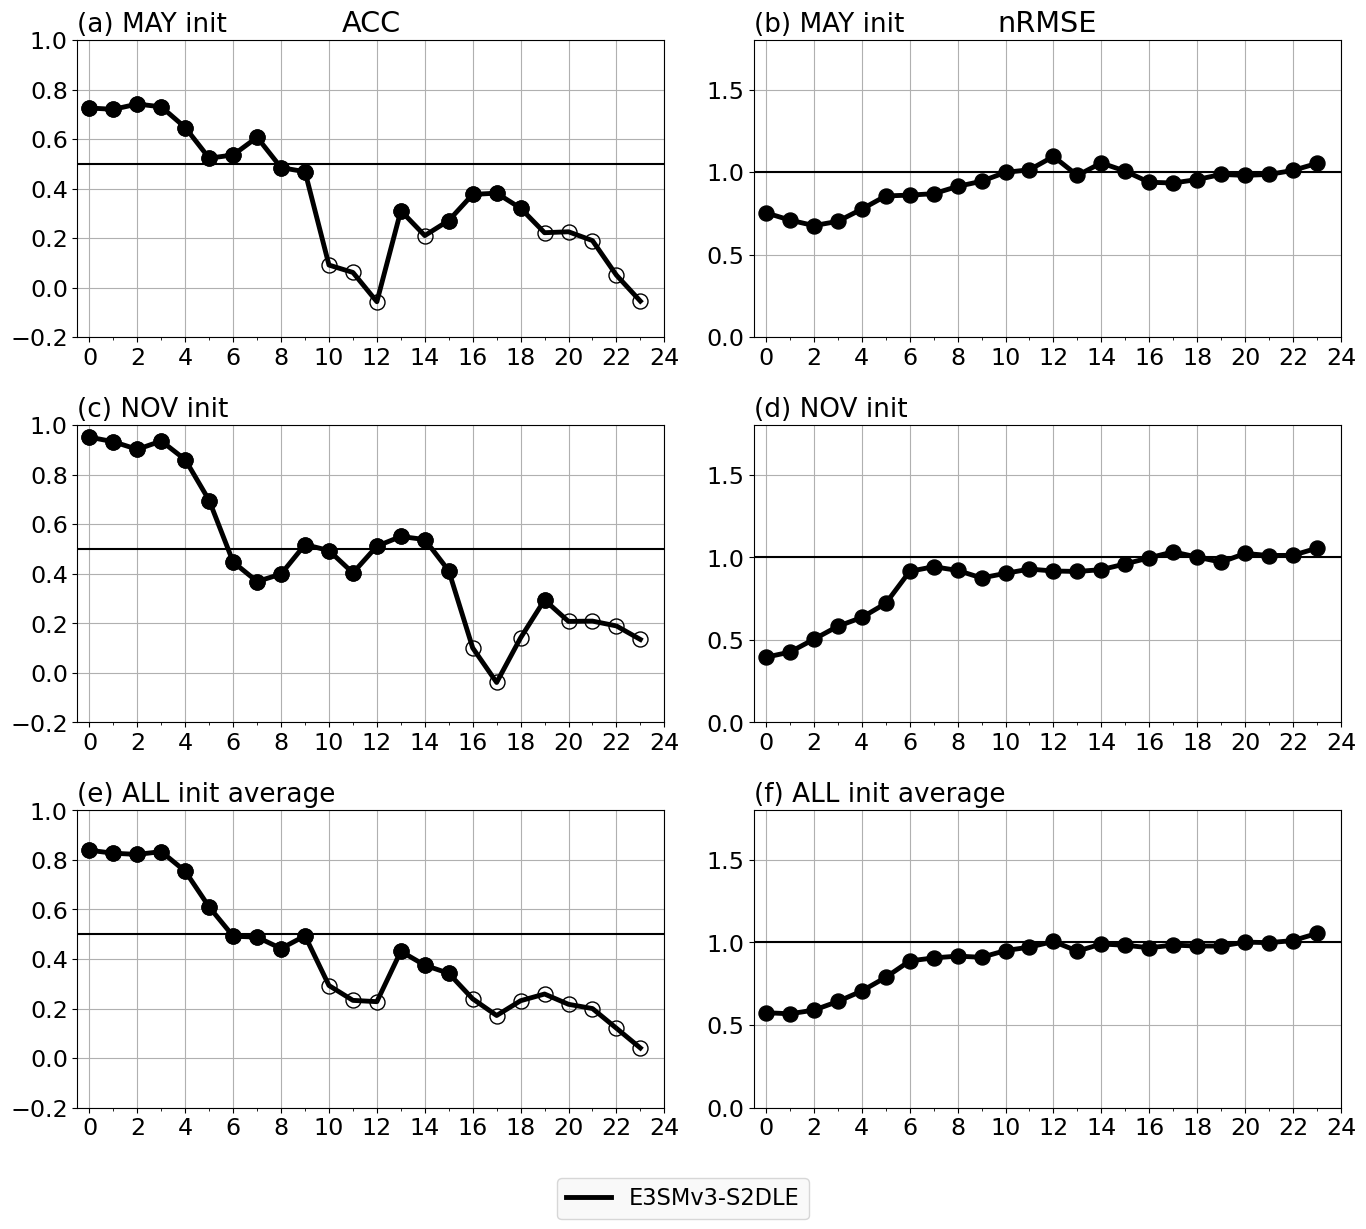

In [23]:

# -----------------------------
# Plot skill scores
# -----------------------------
# -----------------------------
# Plot setup: change values here to tune the figure
# -----------------------------
field = "ELI"
figfmt = "png"
period = f"{START_YEAR}-{END_YEAR}"
figname = figure_filename("eli", "acc_skill", ext=figfmt)
dpi = 300

startmonths_requested = INIT_MONTHS
ncol = 2

fontz = 18
title_fontz = fontz * 1.05
header_fontz = fontz * 1.15
tick_fontz = fontz * 0.95
legend_fontz = fontz * 0.90

fig_width = 14
row_height = fig_width * 0.6 / ncol
line_width = 3.5
marker_size = fontz * 0.6
e3sm_marker_size = marker_size

e3sm_label = "E3SMv3-S2DLE"
e3sm_color = "k"
e3sm_marker = "o"
significance_pval = 0.1
open_marker_fillstyle = "none"
marker_only_linestyle = "none"

hindcast_label = {2: "FEB init", 5: "MAY init", 8: "AUG init", 11: "NOV init"}
all_init_label = "ALL init average"
figlab_fmt = "({})"

monthly_xlim = [-0.5, NLEAD]
acc_ylim = [-0.2, 1.0]
nrmse_ylim = [0.0, 1.8]
acc_hline = 0.5
nrmse_hline = 1.0
hline_color = "black"
show_grid = True
acc_header = "ACC"
nrmse_header = "nRMSE"
monthly_xticks = np.arange(0, NLEAD + 1, 2)
monthly_xticks_minor = np.arange(0, NLEAD + 1, 1)

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": title_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
    "legend.fontsize": legend_fontz,
})

# -----------------------------
# Combine ELI skill arrays for plotting
# -----------------------------
skill_plot = xr.concat(
    [
        xr.Dataset(
            {
                "corr": skill[m]["acc"].rename({"lead": "L"}),
                "pval": skill[m]["pval"].rename({"lead": "L"}),
                "rmse": skill[m]["nrmse"].rename({"lead": "L"}),
                "rmse_degrees": skill[m]["rmse"].rename({"lead": "L"}),
            }
        )
        for m in startmonths_requested
    ],
    dim=xr.DataArray(startmonths_requested, dims="startmonth", name="startmonth"),
)

leadmon = skill_plot.L - 1
startmonths = [m for m in startmonths_requested if m in skill_plot.startmonth.values]
nrow = len(startmonths) + 1
fig = plt.figure(figsize=(fig_width, row_height * nrow))
figlabs = [figlab_fmt.format(chr(97 + i)) for i in range(nrow * ncol)]

# -----------------------------
# Monthly skill panels by initialization month
# -----------------------------
for j, sm in enumerate(startmonths):
    sm_int = int(sm)
    ax = fig.add_subplot(nrow, ncol, j * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, j * 2 + 2)

    label = hindcast_label.get(sm_int, f"{sm_int:02d} init")
    ax.set_title(figlabs[j * 2] + " " + label, loc="left", fontsize=title_fontz)
    ax2.set_title(figlabs[j * 2 + 1] + " " + label, loc="left", fontsize=title_fontz)

    if j == 0:
        ax.set_title(acc_header, loc="center", fontsize=header_fontz)
        ax2.set_title(nrmse_header, loc="center", fontsize=header_fontz)

    tmp = skill_plot.sel(startmonth=sm)

    ax.plot(tmp.L - 1, tmp.corr, color=e3sm_color, linewidth=line_width, label=e3sm_label)
    ax.plot(
        tmp.L - 1,
        tmp.corr,
        color=e3sm_color,
        marker=e3sm_marker,
        markersize=e3sm_marker_size,
        fillstyle=open_marker_fillstyle,
        linestyle=marker_only_linestyle,
    )
    ax.plot(
        tmp.L - 1,
        tmp.corr.where(tmp.pval < significance_pval),
        color=e3sm_color,
        marker=e3sm_marker,
        markersize=e3sm_marker_size,
        linestyle=marker_only_linestyle,
    )

    ax2.plot(
        tmp.L - 1,
        tmp.rmse,
        color=e3sm_color,
        linewidth=line_width,
        marker=e3sm_marker,
        markersize=e3sm_marker_size,
        label=e3sm_label,
    )

    for a, ylim, hline in [(ax, acc_ylim, acc_hline), (ax2, nrmse_ylim, nrmse_hline)]:
        a.set_xticks(monthly_xticks)
        a.set_xticks(monthly_xticks_minor, minor=True)
        a.set_xlim(monthly_xlim)
        a.set_ylim(ylim)
        a.tick_params(axis="both", labelsize=tick_fontz)
        a.grid(show_grid)
        a.axhline(y=hline, color=hline_color)

# -----------------------------
# Monthly ALL-init average panels
# -----------------------------
bottom_row = len(startmonths)
ax = fig.add_subplot(nrow, ncol, bottom_row * 2 + 1)
ax2 = fig.add_subplot(nrow, ncol, bottom_row * 2 + 2)

ax.set_title(figlabs[bottom_row * 2] + " " + all_init_label, loc="left", fontsize=title_fontz)
ax2.set_title(figlabs[bottom_row * 2 + 1] + " " + all_init_label, loc="left", fontsize=title_fontz)

tmp = skill_plot.mean("startmonth")

ax.plot(tmp.L - 1, tmp.corr, color=e3sm_color, linewidth=line_width, label=e3sm_label)
ax.plot(
    tmp.L - 1,
    tmp.corr,
    color=e3sm_color,
    marker=e3sm_marker,
    markersize=e3sm_marker_size,
    fillstyle=open_marker_fillstyle,
    linestyle=marker_only_linestyle,
)
ax.plot(
    tmp.L - 1,
    tmp.corr.where(tmp.pval < significance_pval),
    color=e3sm_color,
    marker=e3sm_marker,
    markersize=e3sm_marker_size,
    linestyle=marker_only_linestyle,
)

ax2.plot(
    tmp.L - 1,
    tmp.rmse,
    color=e3sm_color,
    linewidth=line_width,
    marker=e3sm_marker,
    markersize=e3sm_marker_size,
    label=e3sm_label,
)

for a, ylim, hline in [(ax, acc_ylim, acc_hline), (ax2, nrmse_ylim, nrmse_hline)]:
    a.set_xticks(monthly_xticks)
    a.set_xticks(monthly_xticks_minor, minor=True)
    a.set_xlim(monthly_xlim)
    a.set_ylim(ylim)
    a.tick_params(axis="both", labelsize=tick_fontz)
    a.grid(show_grid)
    a.axhline(y=hline, color=hline_color)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.01),
    frameon=True,
    facecolor="#f9f9f9",
    edgecolor="lightgray",
    framealpha=0.9,
)

fig.tight_layout(rect=[0, 0.06, 1, 1])
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="eli_skill",
    title=f"{field} Skill",
    caption=f"Verification period: {period}",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()


## 7.  Lead-dependent drift diagnostic

Plot the model ELI lead-dependent climatology (drift) for each init month
alongside the observed ELI monthly climatology to assess systematic biases.

Saved: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_eli_drift_clim.png


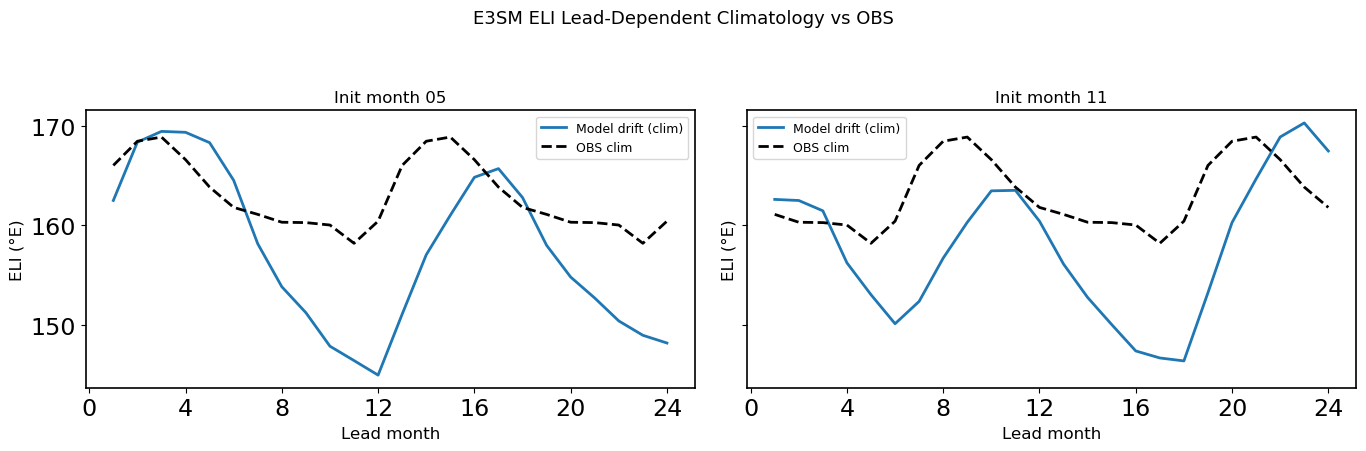

In [24]:
fig, axes = plt.subplots(
    1, len(INIT_MONTHS),
    figsize=(7 * len(INIT_MONTHS), 4.5),
    sharey=True,
)
if len(INIT_MONTHS) == 1:
    axes = [axes]

for ax, m in zip(axes, INIT_MONTHS):
    drift = eli_drift[m].values   # (L,)
    leads = eli_model[m]["L"].values

    # Observed climatological ELI at the target months for each lead.
    obs_clim_leads = [
        float(obs_clim.sel(month=((m - 1 + int(lead)) % 12) + 1))
        for lead in leads
    ]

    ax.plot(leads, drift,          color="tab:blue", linewidth=2,
            label="Model drift (clim)")
    ax.plot(leads, obs_clim_leads, color="k",        linewidth=2,
            linestyle="--", label="OBS clim")

    ax.set_xlabel("Lead month", fontsize=12)
    ax.set_ylabel("ELI (°E)", fontsize=12)
    ax.set_title(f"Init month {m:02d}", fontsize=12)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
    for sp in ax.spines.values():
        sp.set_linewidth(1.2)

fig.suptitle("E3SM ELI Lead-Dependent Climatology vs OBS",
             fontsize=13, y=1.02)
plt.tight_layout()

figname = figure_filename("eli", "drift", "clim")
fig.savefig(FIGURE_OUTDIR / figname, dpi=150, bbox_inches="tight")
print(f"Saved: {FIGURE_OUTDIR / figname}")
plt.show()